In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, minmax_scale
from xgboost import XGBClassifier

from main_event import prepare_event_data, prepare_json_event_data
from preprocessing import PreProcessing
from utils import (
    add_shot_prediction_features,
    calculate_velocity_acceleration,
    calculate_velocity_direction,
    calculate_velocity_acceleration_direction,
    calculate_player_ball_distances,
    get_n_smallest_indices_sorted,
    get_frame_data,
    process_event_data, 
    plot_confusion_matrix, 
    plot_accuracy_history
)

## You'll see the data goes from 0 to 1 on each axis. The coordiante (0,0) is the top left, (1,1) is the bottom right, and (0.5,0.5) is the kick off point.

In [2]:
game_1_pre = PreProcessing()
game_1_data = game_1_pre.load_and_process_data(
    data_home="data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv", 
    data_away="data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [3]:
game_2_pre = PreProcessing()
game_2_data = game_2_pre.load_and_process_data(
    data_home="data/Sample_Game_2/Sample_Game_2_RawTrackingData_Home_Team.csv", 
    data_away="data/Sample_Game_2/Sample_Game_2_RawTrackingData_Away_Team.csv", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [4]:
game_3_pre = PreProcessing()
game_3_data = game_3_pre.load_and_process_json_data(
    data_home_away="data/Sample_Game_3/Sample_Game_3_tracking.txt", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [5]:
# game_1_data.iloc[:, 25:-2] = -1 * game_1_data.iloc[:, 25:-2]
game_1_data

,Period,Frame,Time [s],Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,...,Away-Player21-x,Away-Player21-y,Away-Player22-x,Away-Player22-y,Away-Player23-x,Away-Player23-y,Away-Player24-x,Away-Player24-y,Ball-x,Ball-y
1,1.0,1.0,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,0.50067,0.94322,0.43693,0.05002,0.37833,0.27383,0.45472,0.38709
2,1.0,2.0,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,0.50067,0.94322,0.43693,0.05002,0.37833,0.27383,0.49645,0.40656
3,1.0,3.0,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,0.50067,0.94322,0.43693,0.05002,0.37833,0.27383,0.53716,0.42556
4,1.0,4.0,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,0.50034,0.94391,0.43644,0.05038,0.37756,0.27473,0.55346,0.42231
5,1.0,5.0,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,0.50017,0.94434,0.43580,0.04977,0.37663,0.27543,0.55512,0.40570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145002,2.0,145002.0,5800.08,0.90614,0.45355,0.30044,0.68311,0.34157,0.64598,0.31228,...,0.10317,0.81976,0.19836,0.45137,0.29416,0.48874,0.35600,0.55371,0.03058,0.99726
145003,2.0,145003.0,5800.12,0.90550,0.45355,0.30044,0.68311,0.34127,0.64583,0.31230,...,0.10319,0.81960,0.19831,0.45182,0.29373,0.48836,0.35583,0.55283,0.03058,0.99726
145004,2.0,145004.0,5800.16,0.90492,0.45355,0.30044,0.68311,0.34089,0.64569,0.31214,...,0.10285,0.81944,0.19805,0.45200,0.29331,0.48800,0.35561,0.55254,0.03058,0.99726
145005,2.0,145005.0,5800.20,0.90456,0.45356,0.30044,0.68311,0.34056,0.64552,0.31171,...,0.10231,0.81944,0.19766,0.45237,0.29272,0.48789,0.35532,0.55243,0.03058,0.99726


In [6]:
# game_2_data.iloc[:, 25:-2] = -1 * game_2_data.iloc[:, 25:-2]
game_2_data

,Period,Frame,Time [s],Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,...,Away-Player21-x,Away-Player21-y,Away-Player22-x,Away-Player22-y,Away-Player23-x,Away-Player23-y,Away-Player24-x,Away-Player24-y,Ball-x,Ball-y
1,1.0,1.0,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.43313,0.31354,0.49889,-0.02263,0.50177,0.50145,0.49517,0.36234,0.50216,0.50376
2,1.0,2.0,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.43313,0.31354,0.49889,-0.02263,0.50177,0.50145,0.49517,0.36234,0.50216,0.50376
3,1.0,3.0,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.43313,0.31354,0.49889,-0.02263,0.50177,0.50145,0.49517,0.36234,0.50216,0.50376
4,1.0,4.0,0.16,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.43313,0.31354,0.49889,-0.02263,0.50177,0.50145,0.49517,0.36234,0.50216,0.50376
5,1.0,5.0,0.20,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,...,0.43313,0.31354,0.49889,-0.02263,0.50177,0.50145,0.49517,0.36234,0.50216,0.50376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2.0,141152.0,5646.08,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,...,0.46751,1.05000,0.44966,0.41572,0.26855,0.61845,0.36760,0.12496,0.40958,-0.03891
141153,2.0,141153.0,5646.12,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,...,0.46790,1.05000,0.44983,0.41550,0.26855,0.61845,0.36760,0.12496,0.40958,-0.03891
141154,2.0,141154.0,5646.16,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,...,0.46818,1.05000,0.44997,0.41485,0.26855,0.61845,0.36760,0.12496,0.40958,-0.03891
141155,2.0,141155.0,5646.20,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,...,0.46855,1.05000,0.45017,0.41515,0.26855,0.61845,0.36760,0.12496,0.40958,-0.03891


In [7]:
game_3_data

,Frame,Time [s],Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,...,Away-Player21-x,Away-Player21-y,Away-Player22-x,Away-Player22-y,Away-Player23-x,Away-Player23-y,Away-Player24-x,Away-Player24-y,Ball-x,Ball-y
1,1,0.04,0.84722,0.52855,0.65268,0.24792,0.66525,0.46562,0.68103,0.59083,...,0.41787,0.48086,0.41215,0.36689,0.47050,0.73219,0.48864,0.36357,0.50125,0.48725
2,2,0.08,0.84722,0.52855,0.65231,0.24513,0.66482,0.46548,0.68095,0.59054,...,0.41719,0.47864,0.41132,0.36169,0.47040,0.73204,0.48834,0.36362,0.50125,0.48725
3,3,0.12,0.84722,0.52855,0.65197,0.24387,0.66467,0.46537,0.68078,0.59035,...,0.41697,0.47824,0.41131,0.36072,0.47075,0.73229,0.48814,0.36372,0.50125,0.48725
4,4,0.16,0.84722,0.52855,0.65166,0.24288,0.66460,0.46488,0.68063,0.58987,...,0.41685,0.47815,0.41117,0.35930,0.47118,0.73266,0.48793,0.36278,0.50125,0.48725
5,5,0.20,0.84722,0.52855,0.65141,0.24251,0.66452,0.46469,0.68052,0.58934,...,0.41669,0.47749,0.41120,0.35910,0.47163,0.73287,0.48784,0.36240,0.50125,0.48725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143757,143757,5750.28,0.11993,0.51783,0.47808,0.45408,0.49691,0.77311,0.46373,0.62102,...,0.58877,0.56936,0.50218,0.65158,0.46978,0.62349,0.80792,0.27106,0.89207,0.50485
143758,143758,5750.32,0.11993,0.51783,0.47786,0.45521,0.49701,0.77429,0.46381,0.62046,...,0.58787,0.56961,0.50180,0.65115,0.46970,0.62403,0.80712,0.27184,0.89207,0.50485
143759,143759,5750.36,0.11993,0.51783,0.47743,0.45709,0.49686,0.77555,0.46358,0.62117,...,0.58668,0.57038,0.50116,0.65071,0.46929,0.62479,0.80582,0.27242,0.89207,0.50485
143760,143760,5750.40,0.11993,0.51783,0.47669,0.45947,0.49676,0.77638,0.46306,0.62339,...,0.58525,0.57033,0.50031,0.65134,0.46866,0.62611,0.80444,0.27260,0.89207,0.50485


## Tracking for individual Players Visualization

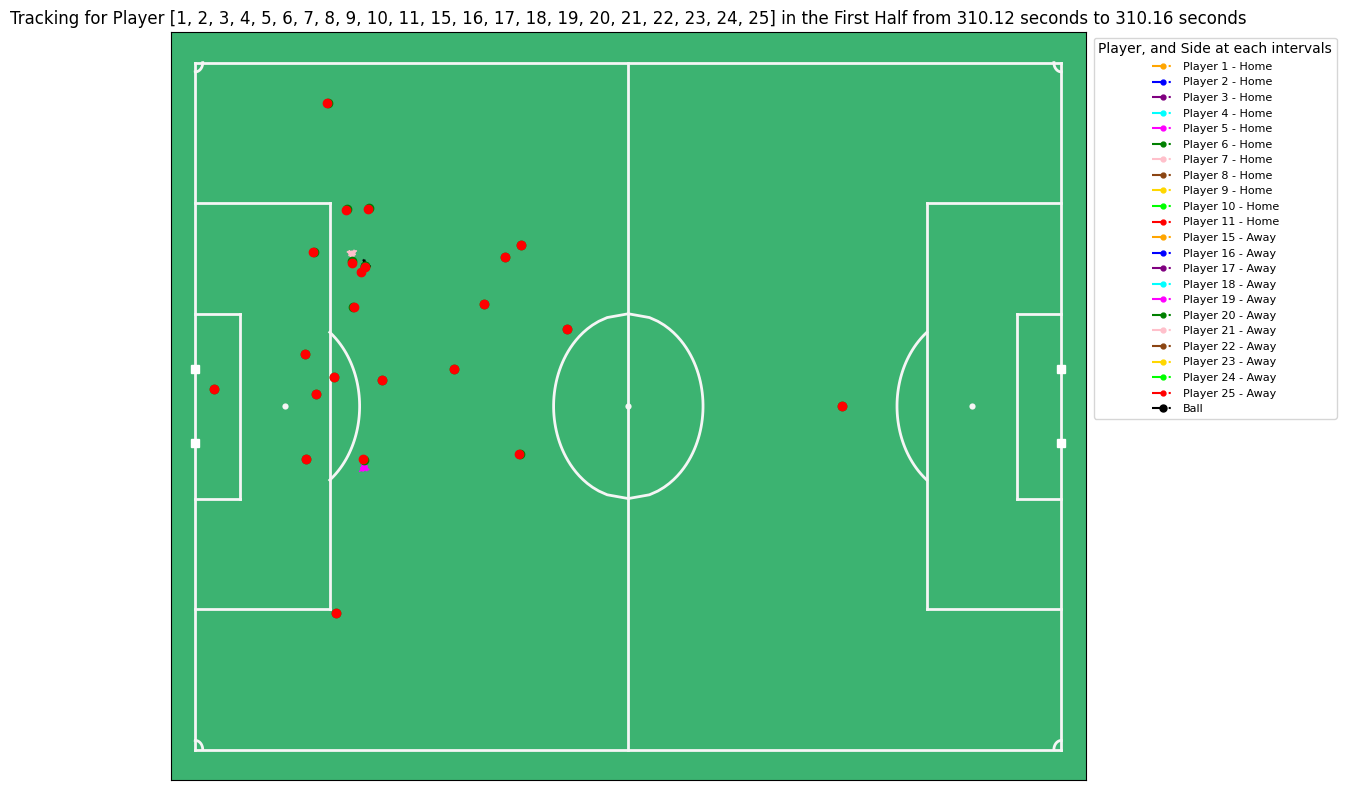

In [8]:
sides = ["Home"] * 11 + ["Away"] * 11
players = list(range(1, 12)) + list(range(15, 26))
game_2_pre.player_visualization(game_1_data.loc[7753:7754], players=players, sides=sides, plot_ball=True)
# game_2_pre.player_visualization(game_2_data.iloc[2:3], players=[1,2,3,4,5,6,7,8,9,10,11], sides=["Home"]*11, plot_ball=False)

In [9]:
# player_tracking(period_1_data)
# player_tracking(period_1_data_home, [2])
# player_tracking(period_1_data_home, [5])
# player_tracking(period_1_data_home, [8])

# Getting the labels

In [10]:
game_1_event = prepare_event_data("data/Sample_Game_1/Sample_Game_1_RawEventsData.csv", game_1_data)
game_2_event = prepare_event_data("data/Sample_Game_2/Sample_Game_2_RawEventsData.csv", game_2_data)
game_3_event = prepare_json_event_data("data/Sample_Game_3/Sample_Game_3_events.json", game_3_data)

In [11]:
game_1_event

,Type
3,PASS
4,PASS
5,PASS
6,PASS
7,PASS
...,...
143614,BALL LOST
143615,BALL LOST
143616,BALL LOST
143617,BALL LOST


In [12]:
game_2_event

,Type
146,PASS
147,PASS
148,PASS
149,PASS
150,PASS
...,...
141152,BALL OUT
141153,BALL OUT
141154,BALL OUT
141155,BALL OUT


In [13]:
game_3_event

,Type
384,PASS
385,PASS
386,PASS
387,PASS
388,PASS
...,...
143529,PASS
143530,PASS
143531,PASS
143532,PASS


In [14]:
common_indices = game_1_event.index.intersection(game_1_event.index)
X_1 = game_1_data.loc[common_indices]
X_1 = X_1.iloc[:, 3:]
y_1 = game_1_event.loc[common_indices]

assert X_1.shape[0] == y_1.shape[0]

In [15]:
common_indices = game_2_event.index.intersection(game_2_event.index)
X_2 = game_2_data.loc[common_indices]
X_2 = X_2.iloc[:, 3:]
y_2 = game_2_event.loc[common_indices]

assert X_2.shape[0] == y_2.shape[0]

In [16]:
common_indices = game_3_event.index.intersection(game_3_event.index)
X_3 = game_3_data.loc[common_indices]
X_3 = X_3.iloc[:, 2:]
y_3 = game_3_event.loc[common_indices]

assert X_3.shape[0] == y_3.shape[0]

In [17]:
X_1

,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,Home-Player4-y,...,Away-Player21-x,Away-Player21-y,Away-Player22-x,Away-Player22-y,Away-Player23-x,Away-Player23-y,Away-Player24-x,Away-Player24-y,Ball-x,Ball-y
3,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,0.35529,0.32137,0.21262,...,0.55243,0.43269,0.50067,0.94322,0.43693,0.05002,0.37833,0.27383,0.53716,0.42556
4,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,0.35554,0.32142,0.21241,...,0.55236,0.43313,0.50034,0.94391,0.43644,0.05038,0.37756,0.27473,0.55346,0.42231
5,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,0.35528,0.32136,0.21159,...,0.55202,0.43311,0.50017,0.94434,0.43580,0.04977,0.37663,0.27543,0.55512,0.40570
6,0.00140,0.48238,0.32581,0.65159,0.33637,0.48966,0.30978,0.35479,0.32159,0.21051,...,0.55157,0.43257,0.49989,0.94432,0.43504,0.04884,0.37557,0.27673,0.55677,0.38909
7,0.00140,0.48238,0.32570,0.65037,0.33624,0.48919,0.31015,0.35439,0.32198,0.20921,...,0.55095,0.43200,0.49952,0.94391,0.43423,0.04805,0.37439,0.27751,0.55842,0.37248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143614,0.87621,0.48890,0.25147,0.54818,0.47196,0.44820,0.50936,0.57808,0.11104,0.67714,...,0.08695,0.63646,0.33917,0.34398,0.45370,0.49248,0.29910,0.56158,0.08382,0.62709
143615,0.87601,0.48911,0.25096,0.54821,0.47157,0.44844,0.50890,0.57796,0.11004,0.67616,...,0.08490,0.63798,0.33752,0.34471,0.45319,0.49318,0.29717,0.56196,0.08062,0.62314
143616,0.87583,0.48933,0.25045,0.54823,0.47120,0.44872,0.50844,0.57788,0.10914,0.67526,...,0.08286,0.63948,0.33588,0.34551,0.45268,0.49386,0.29526,0.56233,0.07743,0.61919
143617,0.87564,0.48954,0.24996,0.54830,0.47084,0.44899,0.50799,0.57768,0.10829,0.67433,...,0.08087,0.64102,0.33427,0.34637,0.45220,0.49465,0.29335,0.56268,0.07423,0.61523


# Smote oversampling

In [18]:
smote = SMOTE(random_state=42)
X_1_oversampled, y_1_oversampled = smote.fit_resample(X_1, y_1)

X_1_oversampled.index = range(1, len(X_1_oversampled) + 1)
y_1_oversampled.index = range(1, len(y_1_oversampled) + 1)

X_1_oversampled.insert(0, "Frame", X_1_oversampled.index)

C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [19]:
smote = SMOTE(random_state=42)
X_2_oversampled, y_2_oversampled = smote.fit_resample(X_2, y_2)

X_2_oversampled.index = range(1, len(X_2_oversampled) + 1)
y_2_oversampled.index = range(1, len(y_2_oversampled) + 1)

X_2_oversampled.insert(0, "Frame", X_2_oversampled.index)

C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [20]:
smote = SMOTE(random_state=42)
X_3_oversampled, y_3_oversampled = smote.fit_resample(X_3, y_3)

X_3_oversampled.index = range(1, len(X_3_oversampled) + 1)
y_3_oversampled.index = range(1, len(y_3_oversampled) + 1)

X_3_oversampled.insert(0, "Frame", X_3_oversampled.index)

C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [21]:
X_3_oversampled

,Frame,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,...,Away-Player21-x,Away-Player21-y,Away-Player22-x,Away-Player22-y,Away-Player23-x,Away-Player23-y,Away-Player24-x,Away-Player24-y,Ball-x,Ball-y
1,1,0.848960,0.508820,0.632850,0.183200,0.737580,0.395660,0.717920,0.664650,0.554290,...,0.423750,0.472840,0.420720,0.365210,0.503490,0.633190,0.498160,0.367620,0.497240,0.485320
2,2,0.849390,0.508640,0.632670,0.182790,0.737730,0.396060,0.717910,0.665120,0.554300,...,0.424240,0.472630,0.421150,0.364850,0.504630,0.632370,0.499000,0.368070,0.498850,0.487020
3,3,0.849870,0.508340,0.632480,0.182550,0.737890,0.396540,0.717910,0.665550,0.554300,...,0.424740,0.472450,0.421600,0.364540,0.505810,0.631550,0.499860,0.368460,0.502070,0.490540
4,4,0.850340,0.508160,0.632300,0.182210,0.738060,0.396920,0.717910,0.666000,0.554300,...,0.425270,0.472280,0.422050,0.364160,0.507030,0.630710,0.500750,0.368860,0.505280,0.494060
5,5,0.850800,0.507990,0.632110,0.181880,0.738200,0.397350,0.717870,0.666520,0.554280,...,0.425780,0.472110,0.422480,0.363690,0.508310,0.629910,0.501670,0.369270,0.508500,0.497570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171580,171580,0.987810,0.512021,0.930701,0.269376,0.899821,0.484320,0.905991,0.525779,0.792284,...,0.790684,0.594078,0.749790,0.292875,0.900021,0.440385,0.917708,0.518731,0.911518,0.597938
171581,171581,0.057604,0.480204,0.564431,0.709759,0.588340,0.840198,0.519718,0.606550,0.714409,...,0.839792,0.661765,0.810743,0.789021,0.555933,0.731033,0.954003,0.475422,0.931651,0.424207
171582,171582,0.939889,0.502062,0.292478,0.437035,0.056466,0.547168,0.050005,0.468916,0.379811,...,0.057223,0.511884,0.027525,0.598041,0.185631,0.501862,0.056755,0.602721,0.002818,0.482137
171583,171583,0.099012,0.507382,0.900873,0.666052,0.480546,0.712038,0.455964,0.524847,0.616990,...,0.899067,0.652128,0.766405,0.765544,0.467662,0.480603,0.463787,0.687486,0.941607,0.588380


# Adding extra features to dataset

In [22]:
vel_acc_game_1_data = calculate_velocity_acceleration_direction(X_1_oversampled)
vel_acc_game_2_data = calculate_velocity_acceleration_direction(X_2_oversampled)
vel_acc_game_3_data = calculate_velocity_acceleration_direction(X_3_oversampled)

In [23]:
vel_acc_game_1_data

,Frame,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,...,P_23_direction_sin,P_23_direction_cos,P_24_velocity,P_24_acceleration,P_24_direction_sin,P_24_direction_cos,Ball_velocity,Ball_acceleration,Ball_direction_sin,Ball_direction_cos
1,1,0.001140,0.482380,0.326480,0.653220,0.337010,0.488630,0.309270,0.355290,0.321370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0.001210,0.482380,0.326220,0.653170,0.336870,0.489880,0.309440,0.355540,0.321420,...,0.592076,-0.805882,-0.726745,NaN,0.759852,-0.650096,-0.668788,NaN,-0.195538,0.980696
3,3,0.001290,0.482380,0.325970,0.652690,0.336640,0.490180,0.309480,0.355280,0.321360,...,-0.689938,-0.723869,-0.726821,-0.000094,0.601374,-0.798968,-0.668518,0.000303,-0.995043,0.099444
4,4,0.001400,0.482380,0.325810,0.651590,0.336370,0.489660,0.309780,0.354790,0.321590,...,-0.774328,-0.632784,-0.724894,0.002201,0.775019,-0.631938,-0.668521,-0.000010,-0.995102,0.098851
5,5,0.001400,0.482380,0.325700,0.650370,0.336240,0.489190,0.310150,0.354390,0.321980,...,-0.698213,-0.715890,-0.725881,-0.001137,0.551433,-0.834219,-0.668521,-0.000006,-0.995102,0.098851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112584,112584,0.130897,0.481270,0.526062,0.683458,0.473219,0.558592,0.472337,0.446915,0.537397,...,0.847041,-0.531527,0.263140,0.008151,-0.040211,-0.999191,-0.359741,-0.330433,-0.416012,0.909359
112585,112585,0.846281,0.491527,0.348971,0.486483,0.522504,0.424979,0.513213,0.557521,0.478872,...,0.966377,0.257128,-0.411833,-0.773031,-0.896232,0.443585,2.487245,3.260554,0.214277,-0.976773
112586,112586,0.284893,0.488296,0.927204,0.480255,0.843366,0.434898,0.936986,0.482878,0.590500,...,-0.208720,0.977975,1.094005,1.724580,0.569397,0.822063,2.735537,0.284355,-0.089142,0.996019
112587,112587,0.296279,0.476207,0.747385,0.478736,0.826202,0.738708,0.807158,0.474073,0.549203,...,-0.978578,-0.205878,0.230536,-0.988909,-0.745343,-0.666681,-0.029685,-3.166925,-0.294729,-0.955581


In [24]:
game_1_ply_tra = vel_acc_game_1_data.iloc[:, 1:]
game_2_ply_tra = vel_acc_game_2_data.iloc[:, 1:]
game_3_ply_tra = vel_acc_game_3_data.iloc[:, 1:]

In [25]:
game_2_ply_tra

,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,Home-Player4-y,...,P_23_direction_sin,P_23_direction_cos,P_24_velocity,P_24_acceleration,P_24_direction_sin,P_24_direction_cos,Ball_velocity,Ball_acceleration,Ball_direction_sin,Ball_direction_cos
1,0.921460,0.491930,0.666690,0.258880,0.684020,0.404180,0.655950,0.550070,0.658750,0.793060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.921050,0.491840,0.667340,0.257380,0.684130,0.403440,0.655920,0.549610,0.659110,0.792020,...,-0.088540,0.996073,-0.841842,NaN,-0.844819,0.535052,-0.819106,NaN,-0.995962,0.089777
3,0.920650,0.491740,0.667960,0.255870,0.684240,0.402570,0.655900,0.549080,0.659470,0.790900,...,-0.095853,0.995396,-0.841823,0.000003,-0.838444,0.544988,-0.819759,-0.000742,-0.997898,0.064799
4,0.920210,0.491710,0.668560,0.254360,0.684330,0.401680,0.655850,0.548610,0.659820,0.789770,...,-0.133133,0.991098,-0.841678,0.000142,-0.872281,0.489006,-0.819723,0.000021,-0.997904,0.064706
5,0.919750,0.491710,0.669150,0.252760,0.684420,0.400800,0.655800,0.548140,0.660150,0.788590,...,-0.176299,0.984337,-0.841174,0.000540,-0.901002,0.433816,-0.819759,-0.000058,-0.997898,0.064799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129348,0.014086,0.508042,0.107613,0.756036,0.085781,0.647035,0.103202,0.494637,0.092277,0.443065,...,-0.174895,-0.984587,1.960730,0.405895,0.306506,-0.951869,2.049687,-0.585378,0.146932,-0.989147
129349,0.221358,0.500192,0.867432,0.939827,0.594602,0.737976,0.557206,0.526537,0.859981,0.761871,...,0.258092,0.966120,1.375518,-0.648887,0.230896,0.972979,1.852608,-0.218535,-0.115501,0.993307
129350,0.223856,0.498517,0.864818,0.937965,0.597680,0.737715,0.563805,0.526148,0.860109,0.752723,...,-0.084671,0.996409,-0.821100,-2.435571,-0.811669,0.584117,-0.463063,-2.567574,-0.853983,0.520302
129351,0.221837,0.499771,0.867046,0.939488,0.595374,0.737977,0.558625,0.526486,0.860093,0.760019,...,0.113123,-0.993581,-0.826130,-0.005596,0.814302,-0.580441,-0.543516,-0.089223,0.853981,-0.520304


In [26]:
# game_1_player_data = get_frame_data(game_1_ply_tra, columns=game_1_ply_tra.columns[0:46:2], feature="direction").fillna(0)
# game_2_player_data = get_frame_data(game_2_ply_tra, columns=game_2_ply_tra.columns[0:46:2], feature="direction").fillna(0)
# game_3_player_data = get_frame_data(game_3_ply_tra, columns=game_3_ply_tra.columns[0:46:2], feature="direction").fillna(0)

In [27]:
game_1_player_data = game_1_ply_tra.fillna(0).copy()
game_2_player_data = game_2_ply_tra.fillna(0).copy()
game_3_player_data = game_3_ply_tra.fillna(0).copy()

In [28]:
game_1_player_data = add_shot_prediction_features(game_1_player_data)
game_2_player_data = add_shot_prediction_features(game_2_player_data)
game_3_player_data = add_shot_prediction_features(game_3_player_data)

X_1_oversampled = game_1_player_data.iloc[:, :]
X_2_oversampled = game_2_player_data.iloc[:, :]
X_3_oversampled = game_3_player_data.iloc[:, :]

In [29]:
game_1_player_data

,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,Home-Player4-y,...,P_23_direction_cos,P_24_velocity,P_24_acceleration,P_24_direction_sin,P_24_direction_cos,Ball_velocity,Ball_acceleration,Ball_direction_sin,Ball_direction_cos,Ball_shot_probability
1,0.001140,0.482380,0.326480,0.653220,0.337010,0.488630,0.309270,0.355290,0.321370,0.212620,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.001210,0.482380,0.326220,0.653170,0.336870,0.489880,0.309440,0.355540,0.321420,0.212410,...,-0.805882,-0.726745,0.000000,0.759852,-0.650096,-0.668788,0.000000,-0.195538,0.980696,0.323544
3,0.001290,0.482380,0.325970,0.652690,0.336640,0.490180,0.309480,0.355280,0.321360,0.211590,...,-0.723869,-0.726821,-0.000094,0.601374,-0.798968,-0.668518,0.000303,-0.995043,0.099444,0.000000
4,0.001400,0.482380,0.325810,0.651590,0.336370,0.489660,0.309780,0.354790,0.321590,0.210510,...,-0.632784,-0.724894,0.002201,0.775019,-0.631938,-0.668521,-0.000010,-0.995102,0.098851,0.000000
5,0.001400,0.482380,0.325700,0.650370,0.336240,0.489190,0.310150,0.354390,0.321980,0.209210,...,-0.715890,-0.725881,-0.001137,0.551433,-0.834219,-0.668521,-0.000006,-0.995102,0.098851,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112584,0.130897,0.481270,0.526062,0.683458,0.473219,0.558592,0.472337,0.446915,0.537397,0.262806,...,-0.531527,0.263140,0.008151,-0.040211,-0.999191,-0.359741,-0.330433,-0.416012,0.909359,0.898590
112585,0.846281,0.491527,0.348971,0.486483,0.522504,0.424979,0.513213,0.557521,0.478872,0.748146,...,0.257128,-0.411833,-0.773031,-0.896232,0.443585,2.487245,3.260554,0.214277,-0.976773,0.940812
112586,0.284893,0.488296,0.927204,0.480255,0.843366,0.434898,0.936986,0.482878,0.590500,0.551386,...,0.977975,1.094005,1.724580,0.569397,0.822063,2.735537,0.284355,-0.089142,0.996019,1.000000
112587,0.296279,0.476207,0.747385,0.478736,0.826202,0.738708,0.807158,0.474073,0.549203,0.388782,...,-0.205878,0.230536,-0.988909,-0.745343,-0.666681,-0.029685,-3.166925,-0.294729,-0.955581,0.000000


### Adding which team has the ball using distance metrics

In [30]:
game_1_players, game_1_ball, game_1_vel_acc = vel_acc_game_1_data.loc[X_1_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_1_data.loc[X_1_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_1_data.loc[X_1_oversampled.index, "P_11_velocity":]
game_2_players, game_2_ball, game_2_vel_acc = vel_acc_game_2_data.loc[X_2_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_2_data.loc[X_2_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_2_data.loc[X_2_oversampled.index, "P_11_velocity":]
game_3_players, game_3_ball, game_3_vel_acc = vel_acc_game_3_data.loc[X_3_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_3_data.loc[X_3_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_3_data.loc[X_3_oversampled.index, "P_11_velocity":]

In [31]:
game_1_result = calculate_player_ball_distances(
    game_data=X_1_oversampled,
    player_data=game_1_players,
    ball_data=game_1_ball
)
game_1_result

,Home-Player11,Home-Player1,Home-Player2,Home-Player3,Home-Player4,Home-Player5,Home-Player6,Home-Player7,Home-Player8,Home-Player9,...,Away-Player15,Away-Player16,Away-Player17,Away-Player18,Away-Player19,Away-Player20,Away-Player21,Away-Player22,Away-Player23,Away-Player24
1,0.539023,0.310186,0.209852,0.238478,0.303165,0.325775,0.131295,0.176923,0.229466,0.046881,...,0.222589,0.145477,0.365426,0.229583,0.090974,0.253186,0.016853,0.518945,0.388685,0.219656
2,0.555507,0.323936,0.226885,0.252990,0.312891,0.335267,0.147990,0.188744,0.234062,0.049654,...,0.215733,0.131024,0.363269,0.241644,0.104642,0.255527,0.010876,0.524298,0.389905,0.229610
3,0.559113,0.336918,0.234244,0.250761,0.303846,0.350554,0.156768,0.182844,0.220835,0.037884,...,0.197277,0.135839,0.378605,0.255965,0.102534,0.272252,0.027585,0.541436,0.375398,0.220973
4,0.563151,0.349641,0.242261,0.249360,0.295297,0.365688,0.166072,0.177541,0.208422,0.031224,...,0.179660,0.142050,0.393339,0.269474,0.102840,0.287690,0.043790,0.558136,0.361370,0.213209
5,0.567758,0.362466,0.250968,0.248928,0.287334,0.380255,0.176221,0.173689,0.196685,0.031224,...,0.162456,0.149593,0.408004,0.282869,0.105487,0.302437,0.059987,0.574458,0.347387,0.207090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112584,0.785389,0.482242,0.468229,0.442267,0.396129,0.244512,0.185612,0.295362,0.100790,0.172755,...,0.099041,0.082719,0.113679,0.324354,0.372018,0.065339,0.152481,0.160635,0.509146,0.443476
112585,0.776945,0.289464,0.473547,0.439584,0.439445,0.144946,0.150139,0.459116,0.162106,0.137109,...,0.044863,0.090494,0.374812,0.223491,0.214463,0.116768,0.079901,0.116131,0.431895,0.481206
112586,0.708863,0.068099,0.161863,0.057985,0.407174,0.299294,0.470940,0.230014,0.064873,0.028342,...,0.095098,0.108643,0.047872,0.133715,0.097346,0.024293,0.071921,0.066023,0.300726,0.175108
112587,0.520184,0.078206,0.299151,0.035241,0.270823,0.396612,0.336605,0.339414,0.213580,0.051864,...,0.050371,0.080659,0.072118,0.106271,0.154628,0.123578,0.158221,0.228102,0.206034,0.079310


In [32]:
game_2_result = calculate_player_ball_distances(
    game_data=X_2_oversampled,
    player_data=game_2_players,
    ball_data=game_2_ball
)
game_2_result

,Home-Player11,Home-Player1,Home-Player2,Home-Player3,Home-Player4,Home-Player5,Home-Player6,Home-Player7,Home-Player8,Home-Player9,...,Away-Player15,Away-Player16,Away-Player17,Away-Player18,Away-Player19,Away-Player20,Away-Player21,Away-Player22,Away-Player23,Away-Player24
1,0.496703,0.342948,0.277024,0.236026,0.373352,0.313091,0.180737,0.153203,0.257618,0.099400,...,0.300610,0.114074,0.135304,0.244139,0.380443,0.000552,0.156475,0.510173,0.154591,0.171414
2,0.495560,0.339008,0.274342,0.236814,0.377921,0.307608,0.177571,0.154230,0.262085,0.094298,...,0.306740,0.118177,0.130822,0.238153,0.385671,0.006124,0.150416,0.503450,0.156447,0.167461
3,0.494714,0.335354,0.272058,0.237919,0.382450,0.302357,0.174755,0.155649,0.266488,0.089655,...,0.312700,0.122323,0.126521,0.232338,0.390834,0.012529,0.144592,0.496938,0.158735,0.163931
4,0.493924,0.331728,0.269874,0.239181,0.387007,0.297109,0.172067,0.157306,0.270939,0.085235,...,0.318660,0.126717,0.122443,0.226515,0.396016,0.019004,0.138811,0.490421,0.161263,0.160582
5,0.493213,0.328212,0.267811,0.240609,0.391537,0.291942,0.169492,0.159178,0.275354,0.081253,...,0.324600,0.131340,0.118528,0.220701,0.401187,0.025408,0.133247,0.483911,0.164015,0.157506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129348,0.204966,0.150801,0.099049,0.152570,0.203074,0.171459,0.060669,0.066524,0.048085,0.200416,...,0.340880,0.285662,0.228680,0.236954,0.303501,0.145036,0.044016,0.231202,0.093368,0.207338
129349,0.718231,0.408949,0.398375,0.381580,0.238113,0.033194,0.228138,0.310578,0.350505,0.086608,...,0.057704,0.060779,0.065038,0.325088,0.262287,0.109894,0.181386,0.122421,0.398375,0.237342
129350,0.772632,0.509580,0.493099,0.438379,0.335664,0.110622,0.312895,0.319992,0.450356,0.196538,...,0.067903,0.068054,0.177321,0.405568,0.352613,0.203959,0.280392,0.148654,0.493099,0.313927
129351,0.728840,0.429928,0.417843,0.391929,0.258593,0.039254,0.245261,0.309368,0.371574,0.109471,...,0.043790,0.048227,0.088393,0.342127,0.280859,0.128688,0.201931,0.121298,0.417843,0.252025


In [33]:
game_3_result = calculate_player_ball_distances(
    game_data=X_3_oversampled,
    player_data=game_3_players,
    ball_data=game_3_ball
)
game_3_result

,Home-Player11,Home-Player1,Home-Player2,Home-Player3,Home-Player4,Home-Player5,Home-Player6,Home-Player7,Home-Player8,Home-Player9,...,Away-Player15,Away-Player16,Away-Player17,Away-Player18,Away-Player19,Away-Player20,Away-Player21,Away-Player22,Away-Player23,Away-Player24
1,0.352504,0.331159,0.256519,0.284357,0.429872,0.378481,0.119092,0.000400,0.180356,0.322257,...,0.346157,0.223549,0.211809,0.328314,0.132664,0.086096,0.074542,0.142414,0.148002,0.117704
2,0.351206,0.332361,0.255612,0.282324,0.428503,0.380764,0.117909,0.003158,0.178264,0.321054,...,0.345420,0.223845,0.213747,0.330944,0.131090,0.085358,0.075985,0.144785,0.145465,0.118950
3,0.348255,0.334462,0.253864,0.277877,0.425091,0.384800,0.115926,0.008345,0.173728,0.318051,...,0.343813,0.224480,0.217718,0.335997,0.128306,0.084851,0.079418,0.149504,0.141060,0.122100
4,0.345348,0.336726,0.252235,0.273450,0.421719,0.388662,0.114108,0.013467,0.169228,0.315148,...,0.342284,0.225251,0.221681,0.341090,0.125653,0.084581,0.082921,0.154277,0.136661,0.125282
5,0.342459,0.339027,0.250612,0.269035,0.418362,0.392650,0.112378,0.018609,0.164744,0.312306,...,0.340763,0.226084,0.225644,0.346147,0.123156,0.084541,0.086549,0.159133,0.132340,0.128482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171580,0.114900,0.329121,0.114219,0.072370,0.119703,0.342608,0.184267,0.238088,0.083968,0.075053,...,0.191741,0.403461,0.400654,0.445953,0.134407,0.195676,0.120896,0.345281,0.157972,0.079448
171581,0.875839,0.465178,0.539362,0.450487,0.227255,0.224913,0.392886,0.192809,0.024717,0.364239,...,0.079670,0.115139,0.206117,0.330045,0.158050,0.095511,0.254700,0.384328,0.485084,0.055881
171582,0.937283,0.293150,0.084303,0.049005,0.406409,0.076062,0.278759,0.486444,0.143830,0.413796,...,0.075967,0.106956,0.089357,0.059981,0.329222,0.143830,0.062006,0.118508,0.183874,0.132098
171583,0.846478,0.087705,0.477355,0.489781,0.401031,0.278685,0.313868,0.193865,0.236234,0.322046,...,0.133697,0.071943,0.115523,0.224337,0.242570,0.097183,0.076638,0.249163,0.486045,0.487989


In [34]:
game_1_closest_to_ball = get_n_smallest_indices_sorted(game_1_result.iloc[:, 1:], 1)
game_2_closest_to_ball = get_n_smallest_indices_sorted(game_2_result.iloc[:, 1:], 1)
game_3_closest_to_ball = get_n_smallest_indices_sorted(game_3_result.iloc[:, 1:], 1)
game_3_closest_to_ball

,P-1
1,Home-Player7
2,Home-Player7
3,Home-Player7
4,Home-Player7
5,Home-Player7
...,...
171580,Home-Player3
171581,Home-Player8
171582,Away-Player25
171583,Away-Player25


In [35]:
def add_ball_with(closest_to_ball: pd.DataFrame):
    # Assume the column of interest is the first column.
    col = closest_to_ball.iloc[:, 0].str.lower()
    
    # Use numpy.where to vectorize the assignment.
    team = np.where(col.str.startswith("home"), 0, 
                    np.where(col.str.startswith("away"), 1, np.nan))
    return team

In [36]:
X_1_oversampled["Team"] = add_ball_with(game_1_closest_to_ball)
X_2_oversampled["Team"] = add_ball_with(game_2_closest_to_ball)
X_3_oversampled["Team"] = add_ball_with(game_3_closest_to_ball)

In [39]:
X_3_oversampled

,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,Home-Player4-y,...,P_24_velocity,P_24_acceleration,P_24_direction_sin,P_24_direction_cos,Ball_velocity,Ball_acceleration,Ball_direction_sin,Ball_direction_cos,Ball_shot_probability,Team
1,0.848960,0.508820,0.632850,0.183200,0.737580,0.395660,0.717920,0.664650,0.554290,0.911390,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.849390,0.508640,0.632670,0.182790,0.737730,0.396060,0.717910,0.665120,0.554300,0.911920,...,-0.833765,0.000000,0.472221,0.881480,-0.828965,0.000000,0.726065,0.687626,0.000000,0.0
3,0.849870,0.508340,0.632480,0.182550,0.737890,0.396540,0.717910,0.665550,0.554300,0.912410,...,-0.833794,-0.000037,0.413005,0.910729,-0.820566,0.009250,0.737850,0.674965,0.000000,0.0
4,0.850340,0.508160,0.632300,0.182210,0.738060,0.396920,0.717910,0.666000,0.554300,0.912920,...,-0.833686,0.000116,0.409939,0.912113,-0.820590,-0.000029,0.738894,0.673821,0.000000,0.0
5,0.850800,0.507990,0.632110,0.181880,0.738200,0.397350,0.717870,0.666520,0.554280,0.913420,...,-0.833577,0.000116,0.407059,0.913402,-0.820592,-0.000006,0.736893,0.676010,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171580,0.987810,0.512021,0.930701,0.269376,0.899821,0.484320,0.905991,0.525779,0.792284,0.608525,...,-0.570972,-0.008070,0.836192,-0.548437,-0.249017,0.050006,0.907659,-0.419708,0.000000,0.0
171581,0.057604,0.480204,0.564431,0.709759,0.588340,0.840198,0.519718,0.606550,0.714409,0.357492,...,-0.641710,-0.077944,-0.766444,0.642311,-0.232428,0.018275,-0.993352,0.115116,0.000000,0.0
171582,0.939889,0.502062,0.292478,0.437035,0.056466,0.547168,0.050005,0.468916,0.379811,0.633940,...,2.295913,3.236723,0.140471,-0.990085,2.380285,2.878732,0.062248,-0.998061,1.000000,1.0
171583,0.099012,0.507382,0.900873,0.666052,0.480546,0.712038,0.455964,0.524847,0.616990,0.352902,...,0.600295,-1.868266,0.203877,0.978997,2.429180,0.053870,0.112452,0.993657,0.975489,1.0


In [39]:
# away_cols = X_1.columns.str.startswith("Away")
# X_1.loc[:, away_cols] = X_1.loc[:, away_cols] * -1

# away_cols = X_2.columns.str.startswith("Away")
# X_2.loc[:, away_cols] = X_2.loc[:, away_cols] * -1

# away_cols = X_3.columns.str.startswith("Away")
# X_3.loc[:, away_cols] = X_3.loc[:, away_cols] * -1

In [40]:
np.unique(y_1_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([28147, 28147, 28147, 28147], dtype=int64))

In [41]:
np.unique(y_2_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([32338, 32338, 32338, 32338], dtype=int64))

In [42]:
np.unique(y_3_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([42896, 42896, 42896, 42896], dtype=int64))

In [43]:
scaler = MinMaxScaler()
X_1_scaled = X_1_oversampled.values#pd.concat([X_1.iloc[:, :46], X_1.iloc[:, -3:]], axis=1).values#scaler.fit_transform(X_1)
X_2_scaled = X_2_oversampled.values#pd.concat([X_2.iloc[:, :46], X_2.iloc[:, -3:]], axis=1).values#scaler.transform(X_2)
X_3_scaled = X_3_oversampled.values#pd.concat([X_3.iloc[:, :46], X_3.iloc[:, -3:]], axis=1).values#scaler.transform(X_3)

# X_1_scaled = minmax_scale(X_1, axis=0)
# X_2_scaled = minmax_scale(X_2, axis=0)
# X_3_scaled = minmax_scale(X_3, axis=0)

label_encoder = LabelEncoder()
y_1_encoded = label_encoder.fit_transform(y_1_oversampled)
y_2_encoded = label_encoder.transform(y_2_oversampled)
y_3_encoded = label_encoder.transform(y_3_oversampled)

C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, )

In [44]:
print(X_1_scaled.shape)
print(X_2_scaled.shape)
print(X_3_scaled.shape)

(112588, 140)
(129352, 140)
(171584, 140)


In [45]:
X_1_scaled = X_1_scaled[:(X_1_scaled.shape[0] - X_1_scaled.shape[0] % 200)]
y_1_encoded = y_1_encoded[:(y_1_encoded.shape[0] - y_1_encoded.shape[0] % 200)]

X_2_scaled = X_2_scaled[:(X_2_scaled.shape[0] - X_2_scaled.shape[0] % 200)]
y_2_encoded = y_2_encoded[:(y_2_encoded.shape[0] - y_2_encoded.shape[0] % 200)]

X_3_scaled = X_3_scaled[:(X_3_scaled.shape[0] - X_3_scaled.shape[0] % 200)]
y_3_encoded = y_3_encoded[:(y_3_encoded.shape[0] - y_3_encoded.shape[0] % 200)]

In [46]:
print(X_1_scaled.shape)
print(X_2_scaled.shape)
print(X_3_scaled.shape)

(112400, 140)
(129200, 140)
(171400, 140)


In [47]:
X = np.concatenate([X_1_scaled, X_2_scaled])
y = np.concatenate((y_1_encoded, y_2_encoded)).ravel()

assert X.shape[0] == y.shape[0]

In [48]:
# %load_ext cuml.accel

In [52]:
models = {
    "AdaBoost classifier": AdaBoostClassifier(learning_rate=1.0, n_estimators=300, random_state=42), 
    "Logistic regression": LogisticRegression(C=0.01, max_iter=500, penalty="l1", solver="saga", random_state=42),
    "Random forest classifier": RandomForestClassifier(criterion="entropy", max_depth=4, max_features="sqrt", min_samples_split=5, n_estimators=50, n_jobs=-1, random_state=42),       
    "XGBoost": XGBClassifier(gamma=0.3, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=50, reg_alpha=1, subsample=0.5, random_state=42)    
}

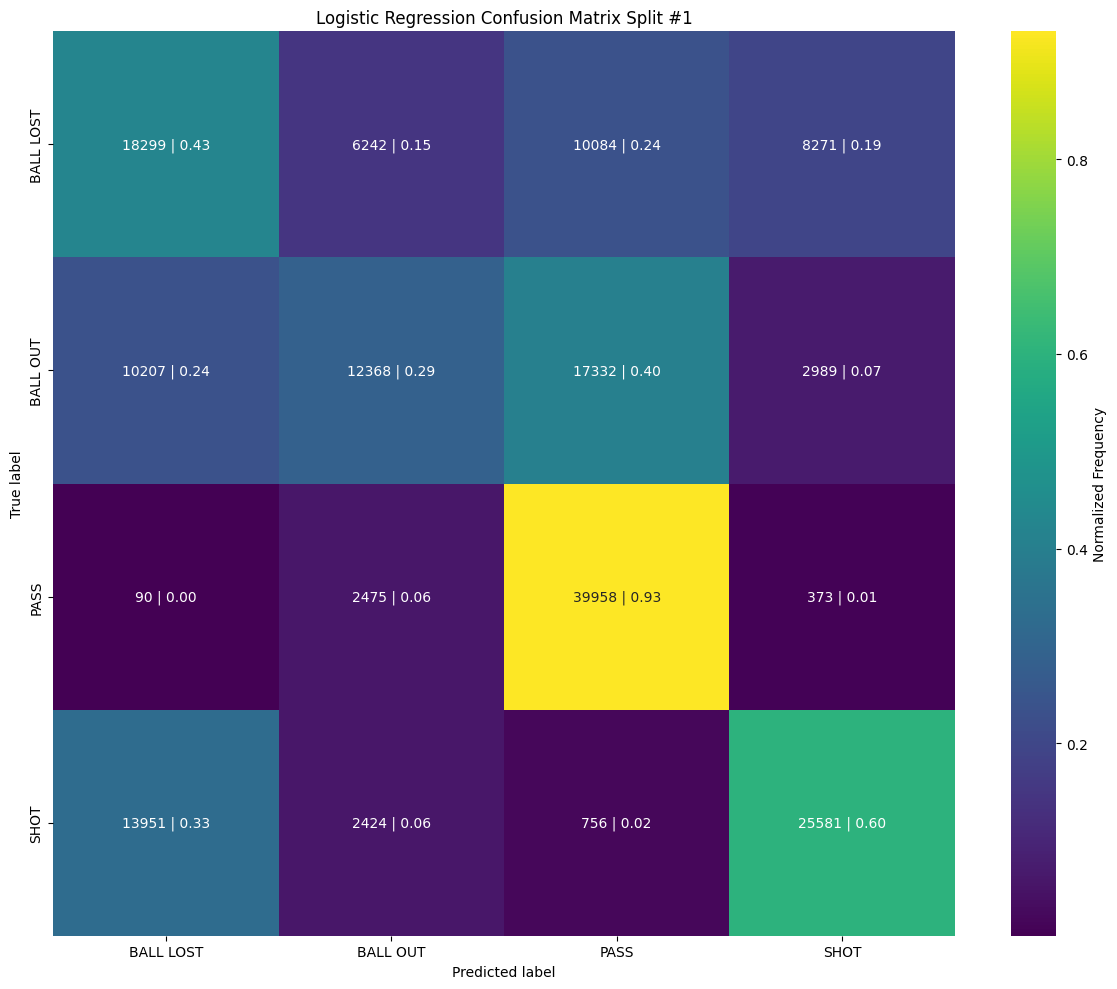

Logistic regression training accuracy: 69.59%
Logistic regression testing accuracy: 56.13%

Logistic regression testing precision: 55.74%
Logistic regression testing recall: 56.13%
Logistic regression testing f1: 54.01%




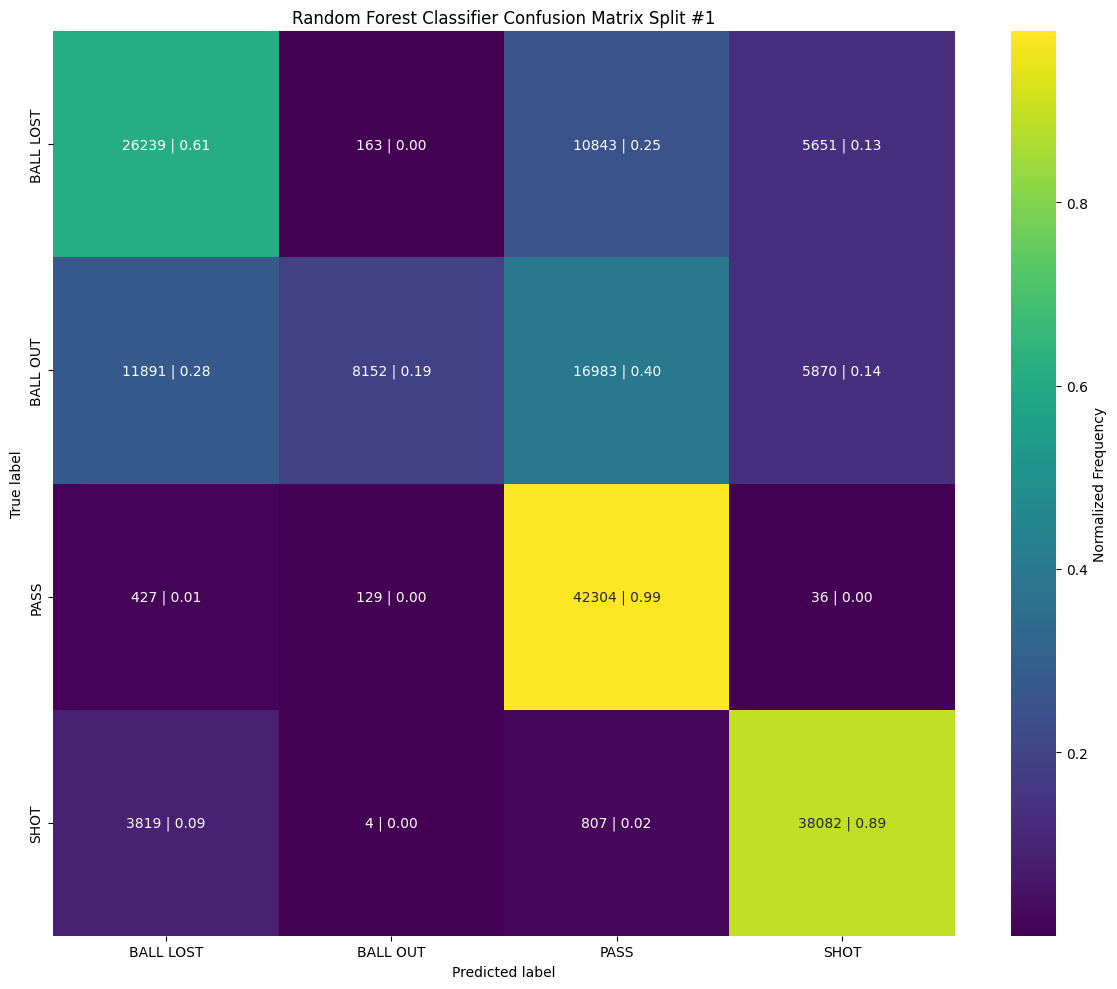

Random forest classifier training accuracy: 76.00%
Random forest classifier testing accuracy: 66.96%

Random forest classifier testing precision: 73.69%
Random forest classifier testing recall: 66.96%
Random forest classifier testing f1: 62.50%




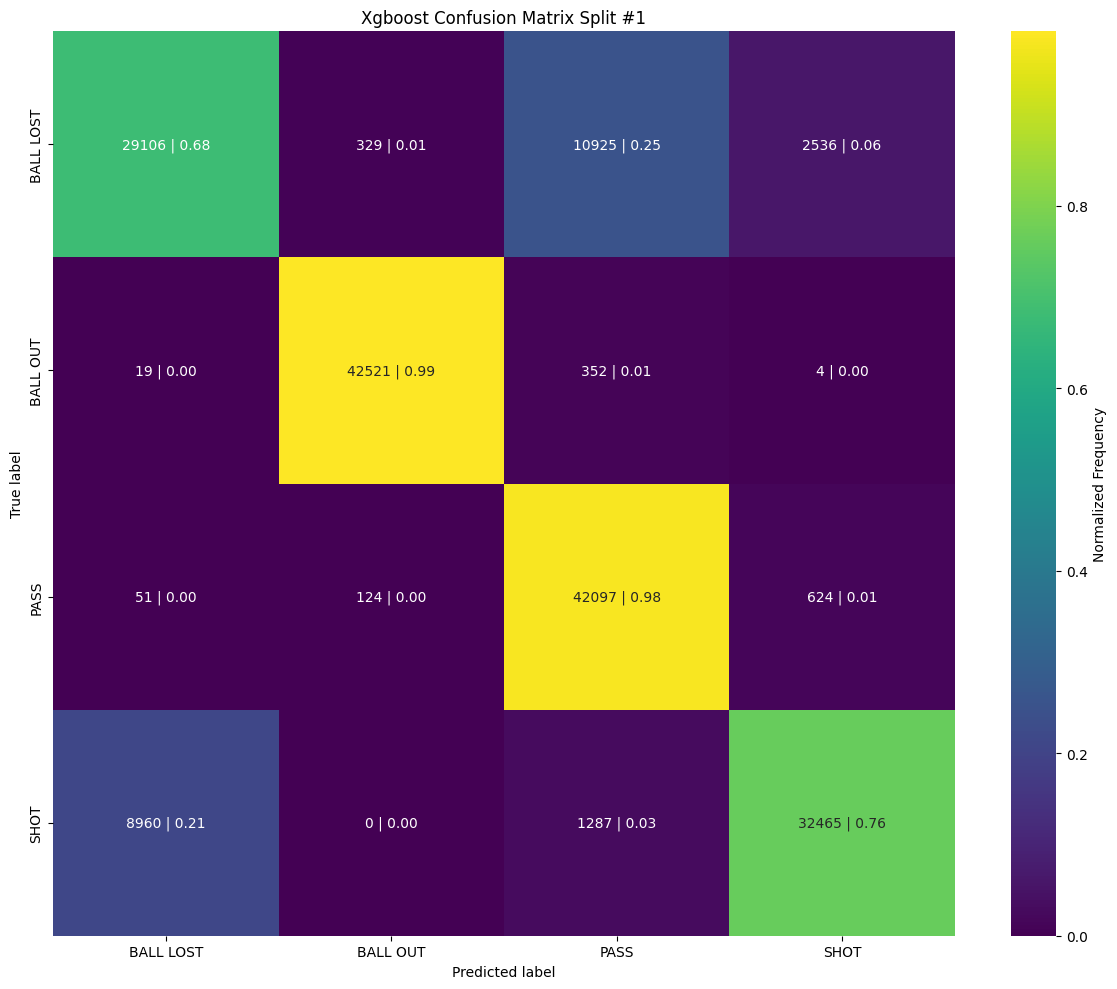

XGBoost training accuracy: 89.53%
XGBoost testing accuracy: 85.29%

XGBoost testing precision: 85.84%
XGBoost testing recall: 85.29%
XGBoost testing f1: 85.02%




In [51]:
# Using standardscaler only
for name, model in models.items():
    model.fit(X, y)
    y_train_pred = model.predict(X)
    y_pred = model.predict(X_3_scaled)    
    labels = label_encoder.inverse_transform(np.unique(y))

    _ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y), 
                              y_train_pred=label_encoder.inverse_transform(y_train_pred), 
                              y_test=label_encoder.inverse_transform(y_3_encoded), 
                              y_pred=label_encoder.inverse_transform(y_pred), 
                              labels=labels, split=0, model_name=name)
    
    # print("\n")

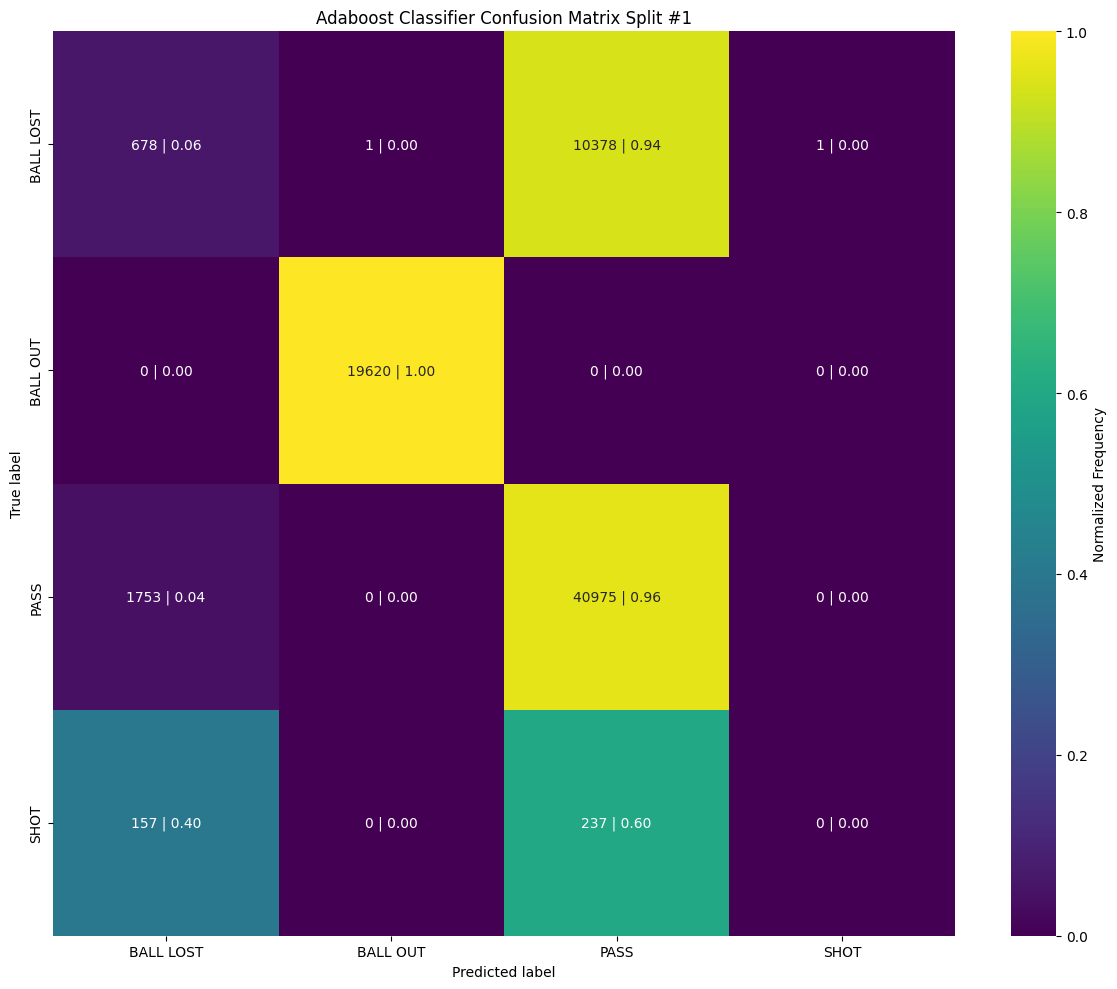

AdaBoost classifier training accuracy: 82.13%
AdaBoost classifier testing accuracy: 83.03%

AdaBoost classifier testing precision: 76.49%
AdaBoost classifier testing recall: 83.03%
AdaBoost classifier testing f1: 78.38%




C:\Users\racr\Desktop\Million's workspace\Thesis-main\Thesis-main\Real-Time LLM Football Commentary\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


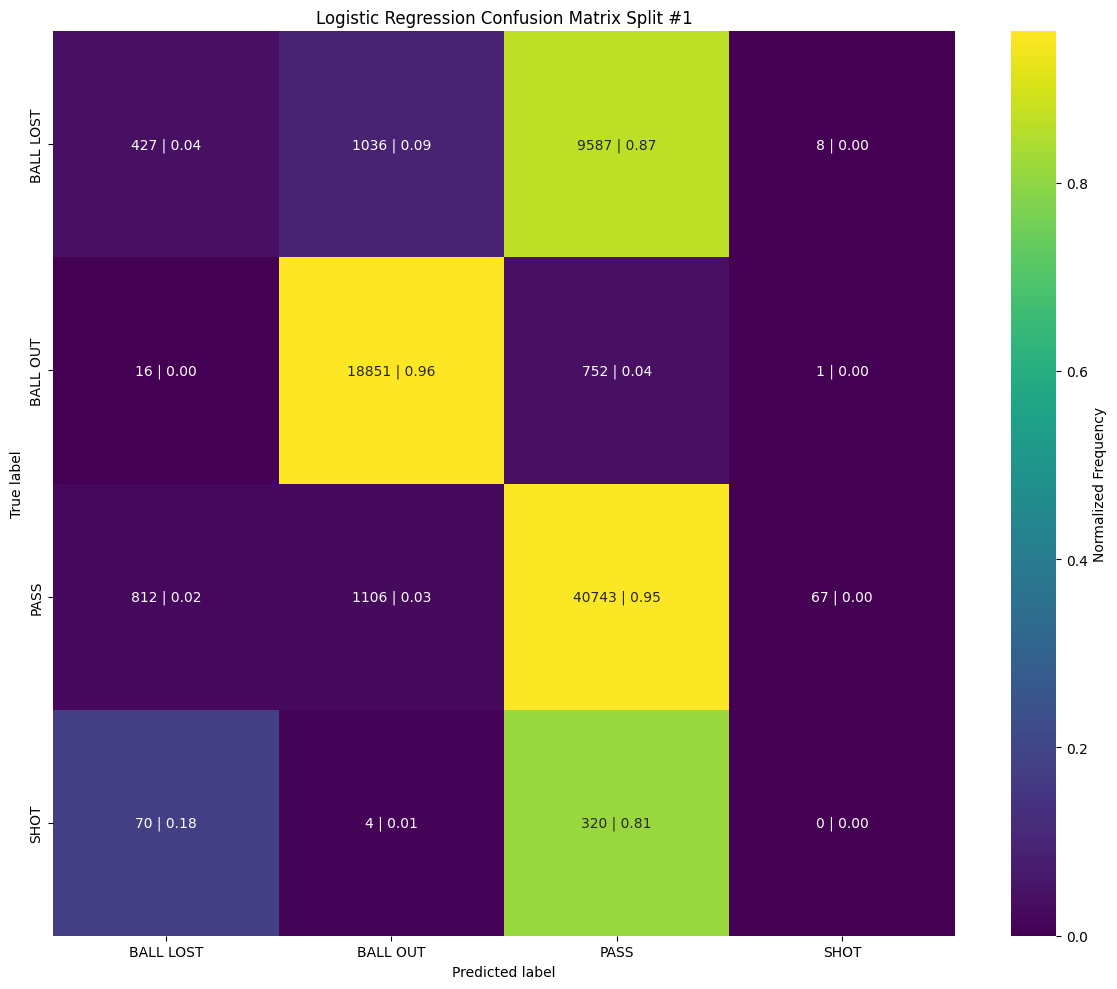

Logistic regression training accuracy: 82.71%
Logistic regression testing accuracy: 81.33%

Logistic regression testing precision: 74.59%
Logistic regression testing recall: 81.33%
Logistic regression testing f1: 75.83%




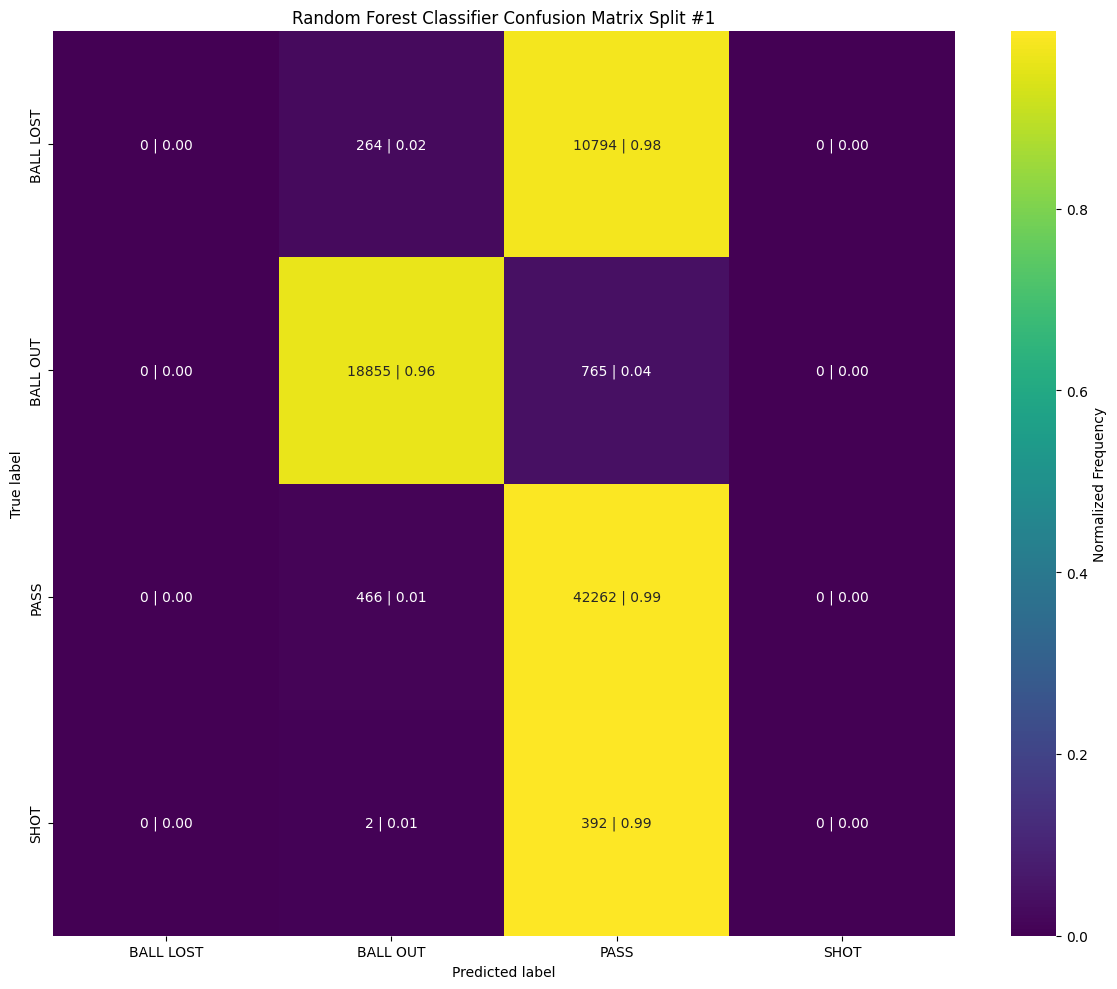

Random forest classifier training accuracy: 82.10%
Random forest classifier testing accuracy: 82.81%

Random forest classifier testing precision: 70.73%
Random forest classifier testing recall: 82.81%
Random forest classifier testing f1: 76.05%




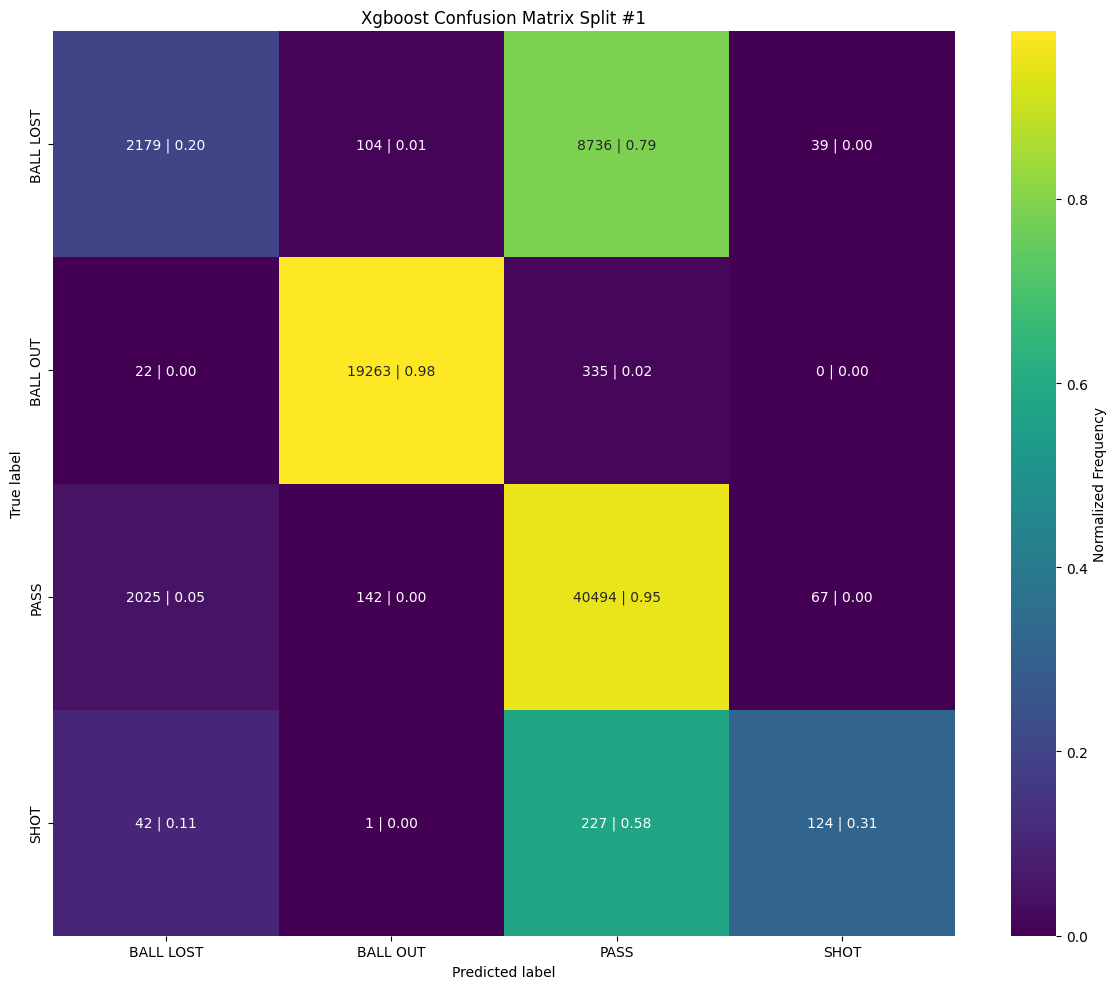

XGBoost training accuracy: 88.71%
XGBoost testing accuracy: 84.09%

XGBoost testing precision: 81.27%
XGBoost testing recall: 84.09%
XGBoost testing f1: 81.33%




In [51]:
# Using standardscaler only
for name, model in models.items():
    model.fit(X, y)
    y_train_pred = model.predict(X)
    y_pred = model.predict(X_3_scaled)    
    labels = label_encoder.inverse_transform(np.unique(y))

    _ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y), 
                              y_train_pred=label_encoder.inverse_transform(y_train_pred), 
                              y_test=label_encoder.inverse_transform(y_3_encoded), 
                              y_pred=label_encoder.inverse_transform(y_pred), 
                              labels=labels, split=0, model_name=name)
    
    # print("\n")


Performing Grid Search for XGBoost...
Fitting 2 folds for each of 46656 candidates, totalling 93312 fits
Best parameters for XGBoost: {'colsample_bytree': 1.0, 'gamma': 0.3, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 50, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.5}


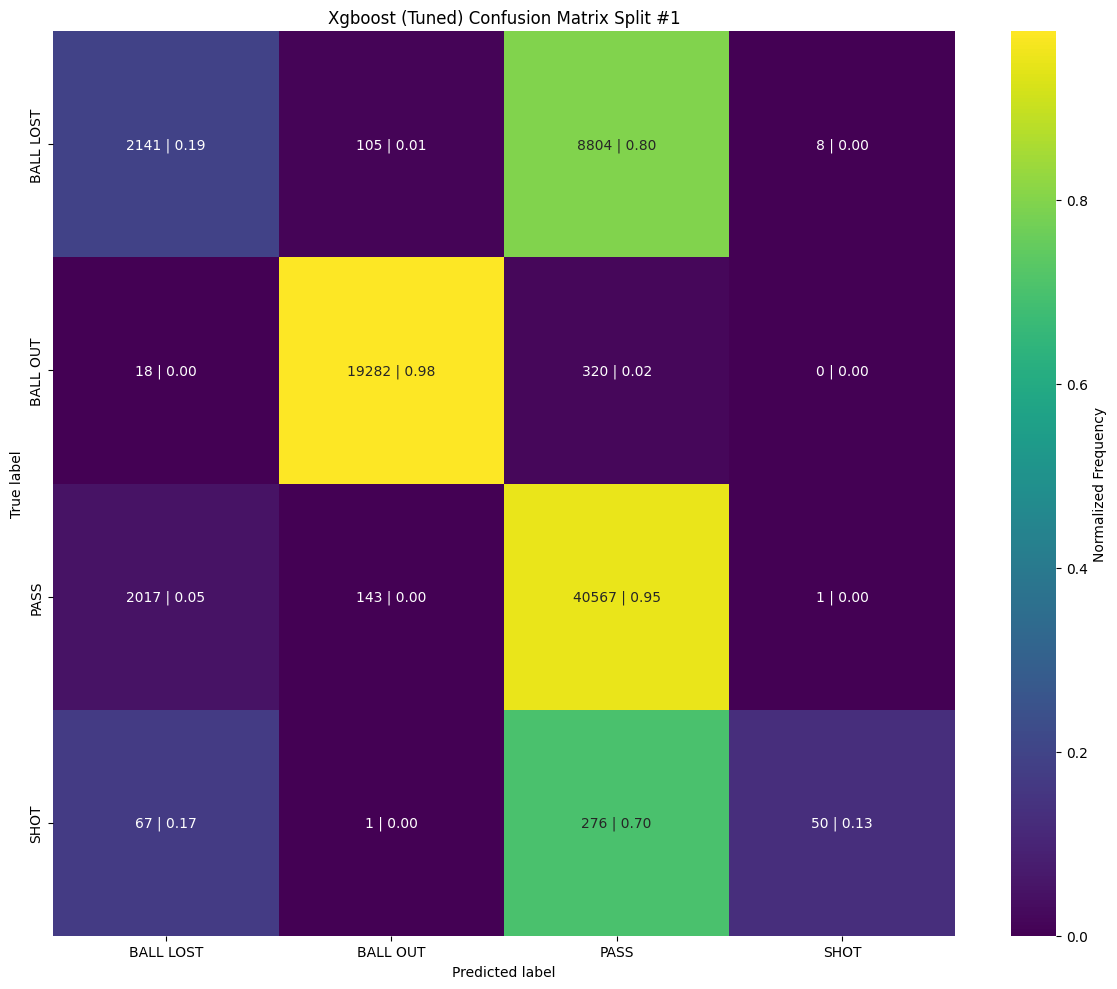

XGBoost (tuned) training accuracy: 88.78%
XGBoost (tuned) testing accuracy: 84.07%

XGBoost (tuned) testing precision: 81.26%
XGBoost (tuned) testing recall: 84.07%
XGBoost (tuned) testing f1: 81.17%




In [50]:
param_grids = {
    # "AdaBoost classifier": {
    #     'n_estimators': [100, 150, 200, 250, 300],
    #     'learning_rate': [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75],
    # },
    # "Logistic regression": {
    #     'penalty': ['l1', 'l2'],
    #     'C': [0.0001, 0.001, 0.01, 0.1, 1],
    #     'solver': ['saga'],
    #     'max_iter': [500, 750, 1000, 1250]
    # },
    # "Random forest classifier": {
    #     'n_estimators': [20, 30, 40, 50, 60, 70],
    #     'max_depth': [4, 5, 6, 7, 8, 9],
    #     'min_samples_split': [3, 4, 5, 6, 7],
    #     "max_features": ["sqrt", "log2"],
    #     'n_jobs': [-1],  # Always use all cores
    #     "criterion": ["entropy", "gini"]
    # }
    "XGBoost": {
        'max_depth': [4, 5, 6, 7],
        'learning_rate': [0.001, 0.01, 0.1],
        'min_child_weight': [1, 2, 3],
        'subsample': [0.5, 0.75, 1.0],
        'n_estimators': [50, 75, 100, 150],
        'colsample_bytree': [0.5, 0.75, 1.0],
        'gamma': [0, 0.15, 0.3],
        'reg_alpha': [0, 0.25, 0.5, 1],
        'reg_lambda': [1, 3, 5]
    }
}

# Dictionary to store best models
best_models = {}

for name, model in models.items():
    print(f"\nPerforming Grid Search for {name}...")

    grid_search = GridSearchCV(model, param_grids[name], cv=2, n_jobs=-1, verbose=4)
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    
    # Predict and evaluate
    y_train_pred = best_model.predict(X)
    y_pred = best_model.predict(X_3_scaled)
    labels = label_encoder.inverse_transform(np.unique(y))

    _ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y), 
                              y_train_pred=label_encoder.inverse_transform(y_train_pred), 
                              y_test=label_encoder.inverse_transform(y_3_encoded), 
                              y_pred=label_encoder.inverse_transform(y_pred), 
                              labels=labels, split=0, model_name=f"{name} (tuned)")



Performing Grid Search for AdaBoost classifier...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters for AdaBoost classifier: {'learning_rate': 1.0, 'n_estimators': 200}


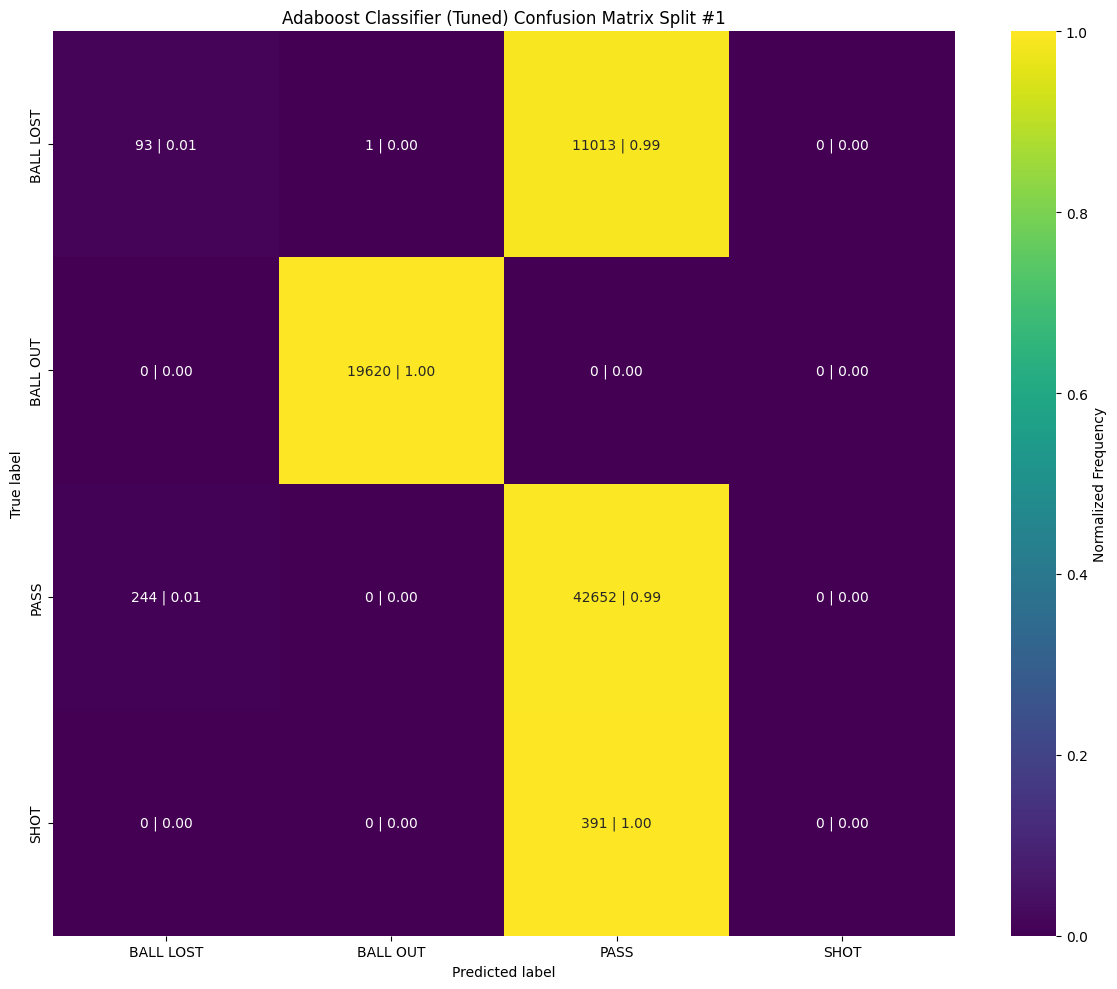

AdaBoost classifier (tuned) training accuracy: 83.20%
AdaBoost classifier (tuned) testing accuracy: 84.26%

AdaBoost classifier (tuned) testing precision: 76.38%
AdaBoost classifier (tuned) testing recall: 84.26%
AdaBoost classifier (tuned) testing f1: 77.75%



Performing Grid Search for Logistic regression...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters for Logistic regression: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}


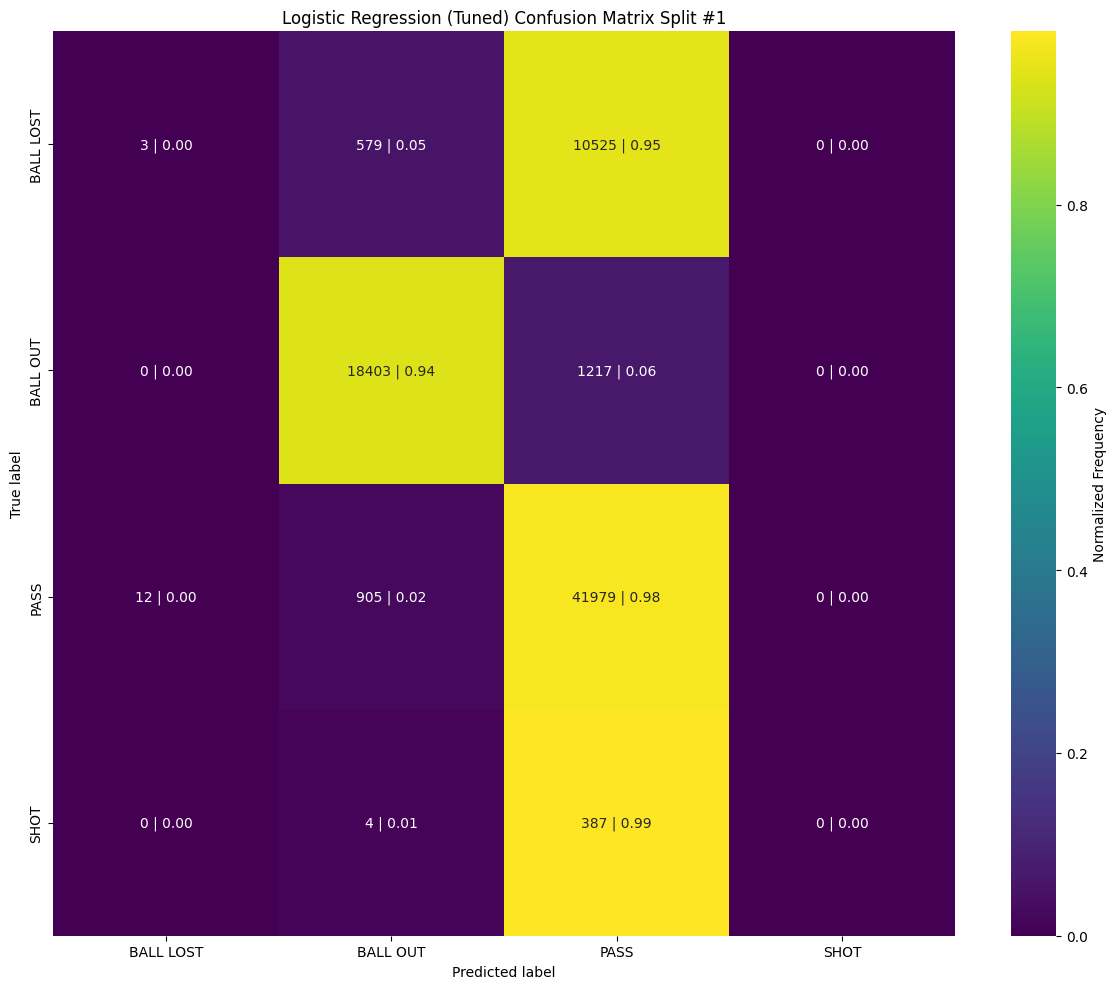

Logistic regression (tuned) training accuracy: 80.26%
Logistic regression (tuned) testing accuracy: 81.59%

Logistic regression (tuned) testing precision: 72.49%
Logistic regression (tuned) testing recall: 81.59%
Logistic regression (tuned) testing f1: 74.86%



Performing Grid Search for Random forest classifier...
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters for Random forest classifier: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50, 'n_jobs': -1}


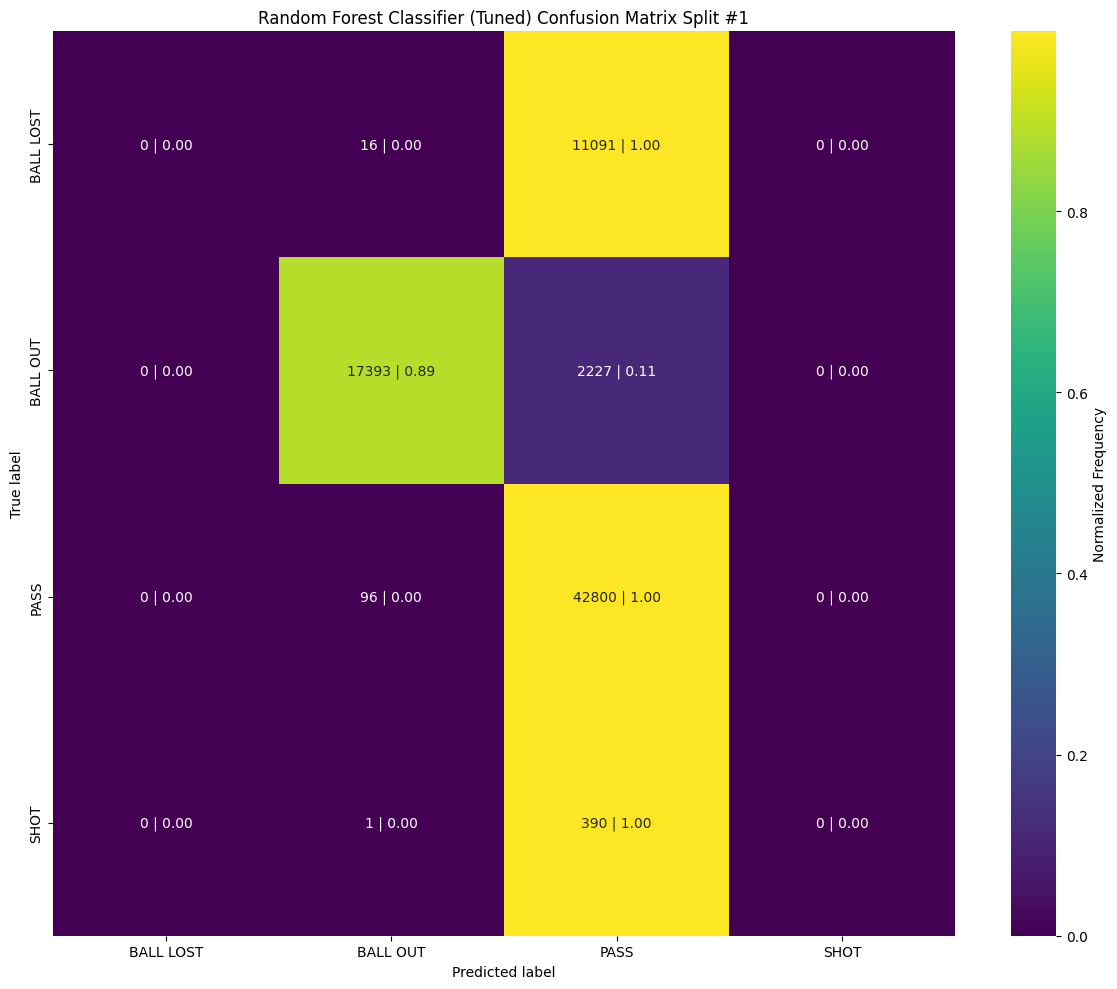

Random forest classifier (tuned) training accuracy: 82.42%
Random forest classifier (tuned) testing accuracy: 81.33%

Random forest classifier (tuned) testing precision: 70.23%
Random forest classifier (tuned) testing recall: 81.33%
Random forest classifier (tuned) testing f1: 74.75%




In [44]:
param_grids = {
    "AdaBoost classifier": {
        'n_estimators': [100, 150, 200, 250, 300],
        'learning_rate': [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75],
    },
    "Logistic regression": {
        'penalty': ['l1', 'l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 1],
        'solver': ['saga'],
        'max_iter': [500, 750, 1000, 1250]
    },
    "Random forest classifier": {
        'n_estimators': [20, 30, 40, 50, 60, 70],
        'max_depth': [4, 5, 6, 7, 8, 9],
        'min_samples_split': [3, 4, 5, 6, 7],
        "max_features": ["sqrt", "log2"],
        'n_jobs': [-1],  # Always use all cores
        "criterion": ["entropy", "gini"]
    }
}

# Dictionary to store best models
best_models = {}

for name, model in models.items():
    print(f"\nPerforming Grid Search for {name}...")

    grid_search = GridSearchCV(model, param_grids[name], cv=3, n_jobs=-1, verbose=4)
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    
    # Predict and evaluate
    y_train_pred = best_model.predict(X)
    y_pred = best_model.predict(X_3_scaled)
    labels = np.unique(y)
    
    _ = plot_confusion_matrix(
        y_train=y,
        y_train_pred=y_train_pred,
        y_test=y_3,
        y_pred=y_pred,
        labels=labels,
        split=0,
        model_name=f"{name} (tuned)"
    )



Performing Grid Search for AdaBoost classifier...
Fitting 3 folds for each of 35 candidates, totalling 105 fits
Best parameters for AdaBoost classifier: {'learning_rate': 1.0, 'n_estimators': 300}


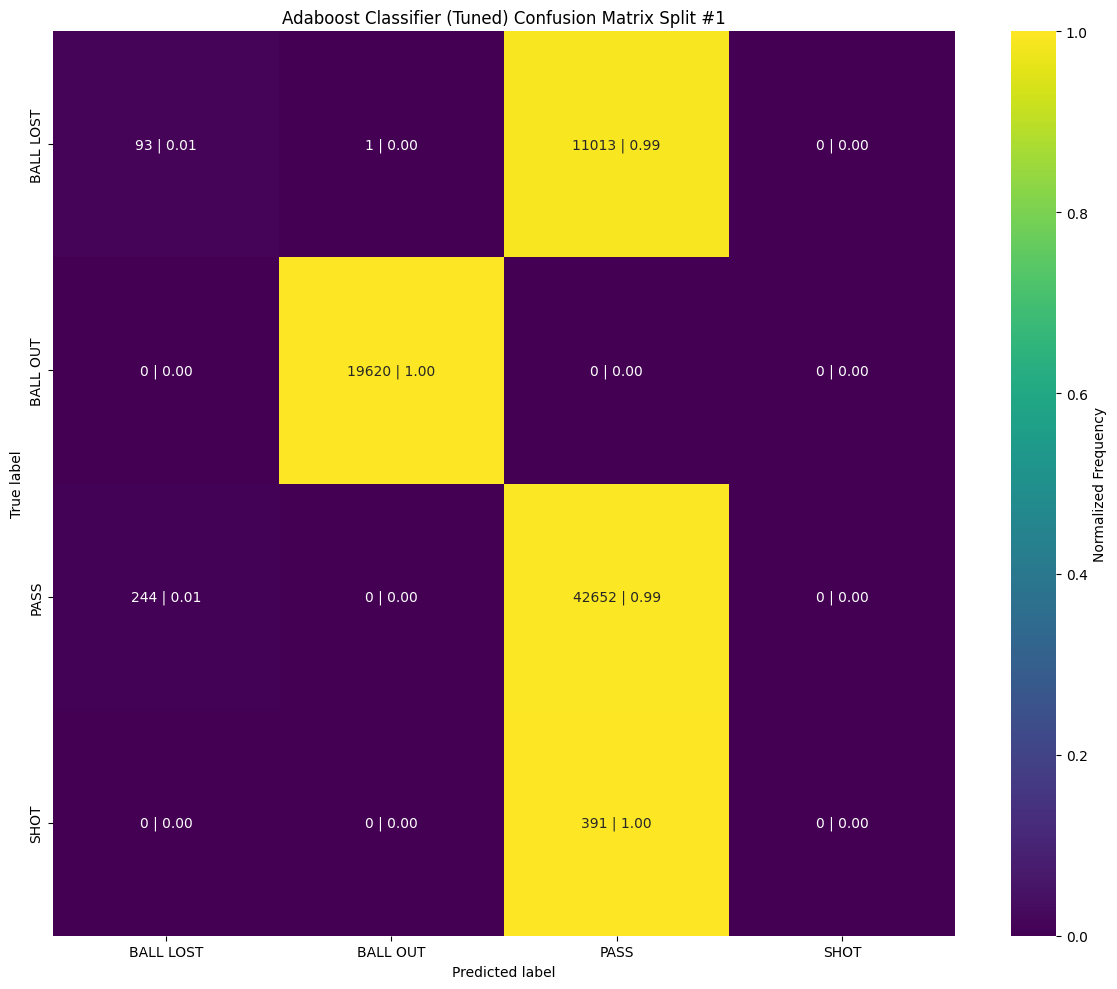

AdaBoost classifier (tuned) training accuracy: 83.20%
AdaBoost classifier (tuned) testing accuracy: 84.26%

AdaBoost classifier (tuned) testing precision: 76.38%
AdaBoost classifier (tuned) testing recall: 84.26%
AdaBoost classifier (tuned) testing f1: 77.75%



Performing Grid Search for Logistic regression...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters for Logistic regression: {'C': 0.01, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}


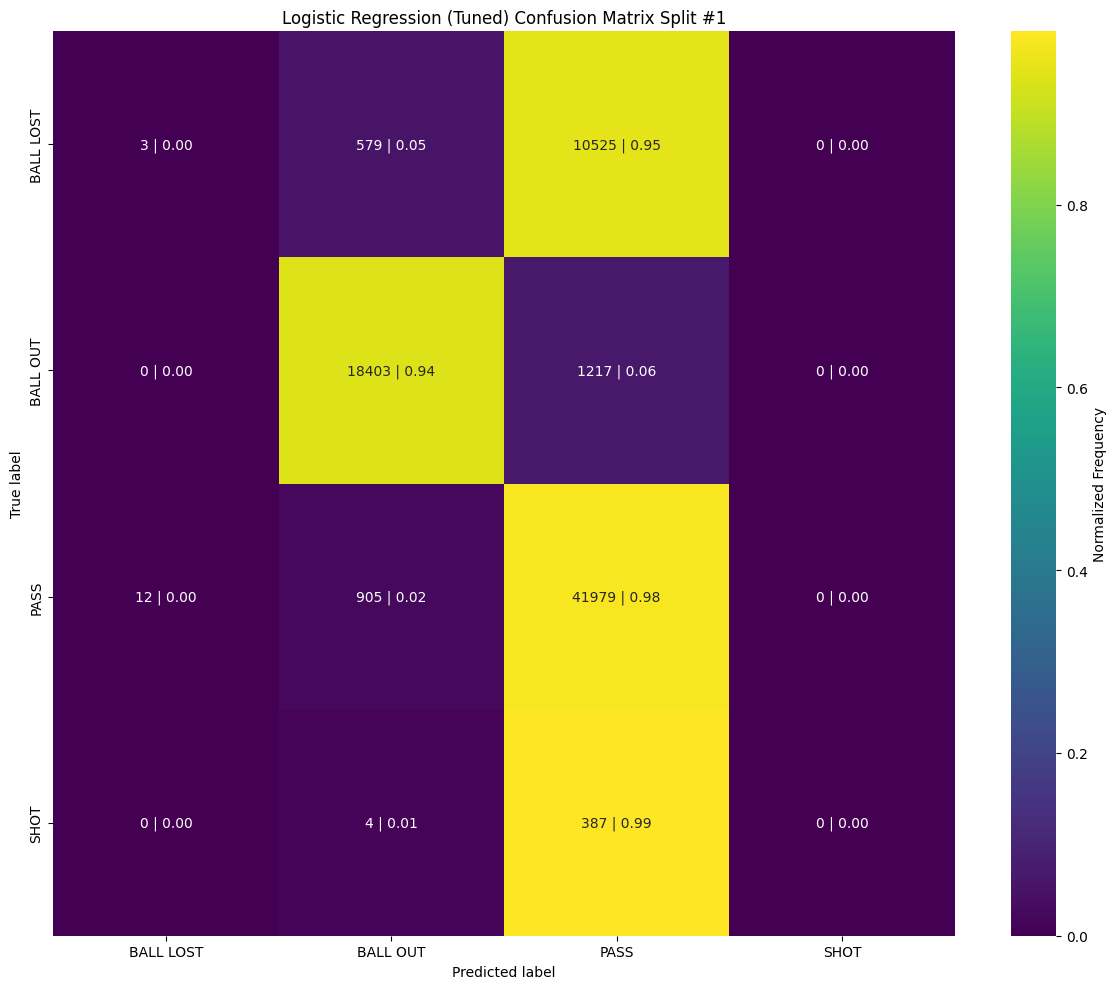

Logistic regression (tuned) training accuracy: 80.26%
Logistic regression (tuned) testing accuracy: 81.59%

Logistic regression (tuned) testing precision: 72.49%
Logistic regression (tuned) testing recall: 81.59%
Logistic regression (tuned) testing f1: 74.86%



Performing Grid Search for Random forest classifier...
Fitting 3 folds for each of 720 candidates, totalling 2160 fits
Best parameters for Random forest classifier: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50, 'n_jobs': -1}


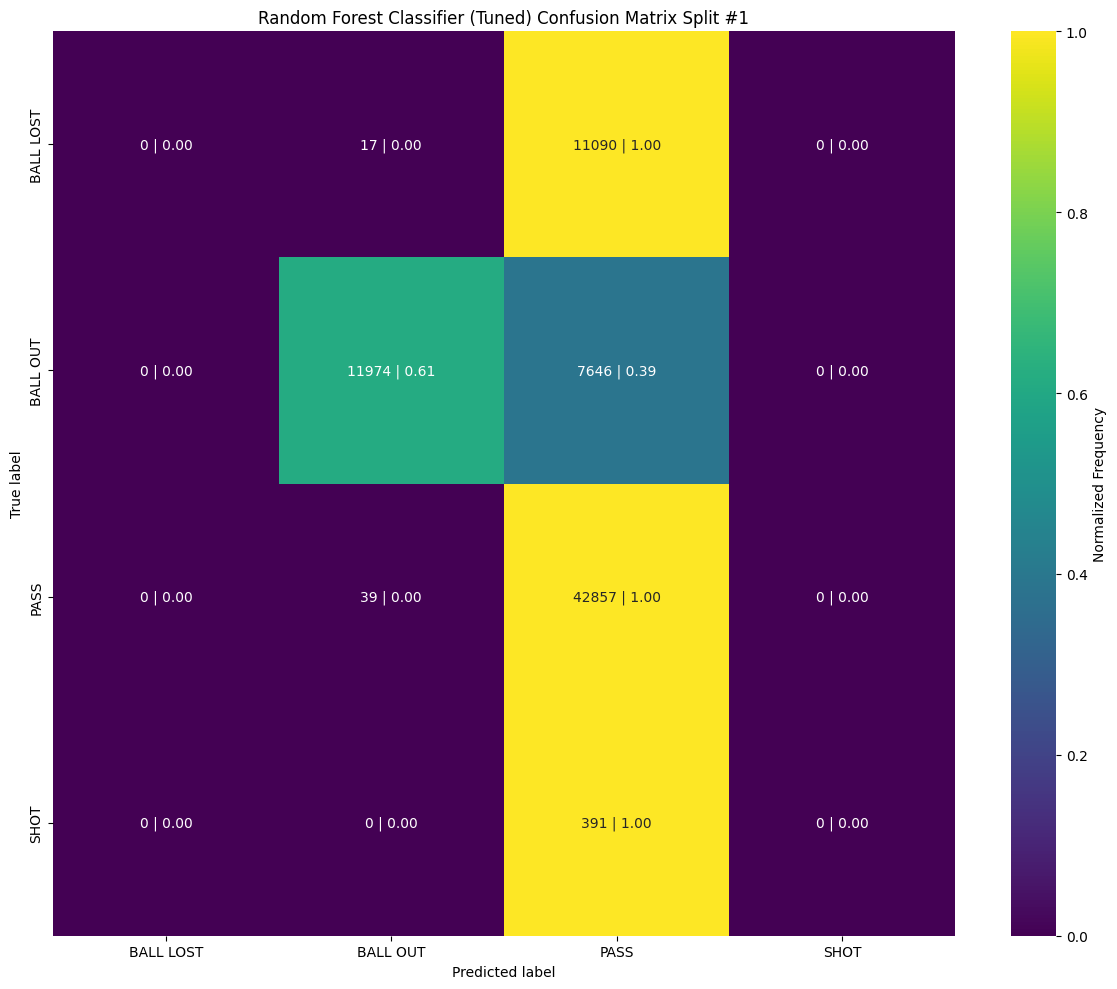

Random forest classifier (tuned) training accuracy: 81.03%
Random forest classifier (tuned) testing accuracy: 74.08%

Random forest classifier (tuned) testing precision: 66.46%
Random forest classifier (tuned) testing recall: 74.08%
Random forest classifier (tuned) testing f1: 67.42%




In [45]:
param_grids = {
    "AdaBoost classifier": {
        'n_estimators': [100, 150, 200, 250, 300],
        'learning_rate': [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75],
    },
    "Logistic regression": {
        'penalty': ['l1', 'l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 1],
        'solver': ['saga'],
        'max_iter': [500, 750, 1000, 1250]
    },
    "Random forest classifier": {
        'n_estimators': [20, 30, 40, 50, 60, 70],
        'max_depth': [4, 5, 6, 7, 8, 9],
        'min_samples_split': [3, 4, 5, 6, 7],
        "max_features": ["sqrt", "log2"],
        'n_jobs': [-1],  # Always use all cores
        "criterion": ["entropy", "gini"]
    }
}

# Dictionary to store best models
best_models = {}

for name, model in models.items():
    print(f"\nPerforming Grid Search for {name}...")

    grid_search = GridSearchCV(model, param_grids[name], cv=3, n_jobs=-1, verbose=4)
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    
    # Predict and evaluate
    y_train_pred = best_model.predict(X)
    y_pred = best_model.predict(X_3_scaled)
    labels = np.unique(y)
    
    _ = plot_confusion_matrix(
        y_train=y,
        y_train_pred=y_train_pred,
        y_test=y_3,
        y_pred=y_pred,
        labels=labels,
        split=0,
        model_name=f"{name} (tuned)"
    )
